# CNN入門: MNIST Digitsを分類しよう

この notebook では，CNN を使って手書き数字を分類する。
題材は MNIST Digits で，画像分類の最初の練習としてよく使われるデータセットである。

ひらがなや犬猫写真よりも，MNIST はかなり簡単である。
だからここでは，CNN の部品を一つずつ見ながら，「動かすと何が起きるか」を試すことを目標にする。


## CNN の全体像

CNN は，画像をいきなり全部見るのではなく，小さな範囲を少しずつ見ながら手がかりを探すモデルである。

1. 画像を読み込む
2. `Conv2d` で線や角のような手がかりを探す
3. `MaxPool2d` で近い場所の情報をまとめる
4. `Flatten` で画像の形を1列の数字に直す
5. `Linear` で「0から9のどれか」の点数を出す

数式を覚えるより先に，画像を入れて，学習して，予測を見る。
それで十分に CNN の雰囲気はつかめる。

```{figure} ../assets/digit_5_cnn_architecture.svg
:alt: 数字5の画像が畳み込み層，プーリング層，全結合層を通って分類結果になる流れを示すCNNの図
:width: 100%

数字の画像が，畳み込み層，プーリング層，全結合層を通って，最後に分類結果へ変わる流れ。
```

この図では，左の小さな数字画像から始まり，右へ進むほど「どこに線があるか」「どんな形に見えるか」という情報へ変わっていく。
最初は画像そのものに近く，最後は 0 から 9 までの点数になる。


## 準備

まずはライブラリを読み込む。
初回実行時は MNIST のデータを `data/` にダウンロードする。


In [1]:
from __future__ import annotations

import json
import random
import re
import tempfile
import unicodedata
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=Warning, module=r"tqdm\.auto")

import matplotlib.pyplot as plt
import numpy as np
import torch
import transformers
from jaxtyping import Float, Int64
from matplotlib import font_manager
from PIL import Image
from sklearn.metrics import accuracy_score
from torch import nn
from torch.utils.data import Dataset, Subset
from torchvision import datasets, transforms
from transformers import Trainer, TrainingArguments
from transformers.trainer_utils import EvalPrediction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DATA_ROOT = Path("data") if Path("data").exists() else Path("../data")

JAPANESE_FONT_CANDIDATES = [
    "Hiragino Sans",
    "Hiragino Maru Gothic Pro",
    "YuGothic",
    "Noto Sans CJK JP",
    "Arial Unicode MS",
]
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
for font_name in JAPANESE_FONT_CANDIDATES:
    if font_name in available_font_names:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

print(f"device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")


device: mps
PyTorch: 2.11.0
Transformers: 5.8.1


## MNIST を用意する

MNIST は 28 x 28 ピクセルの白黒画像で，正解ラベルは 0 から 9 の数字である。
授業で待ち時間が長くならないように，ここでは各数字から一部だけを取り出して使う。


In [2]:
TRAIN_SAMPLES_PER_LABEL = 600
EVAL_SAMPLES_PER_LABEL = 100

base_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=8,
        translate=(0.08, 0.08),
        scale=(0.92, 1.08),
        fill=0,
    ),
    transforms.ToTensor(),
])


def balanced_indices(labels: torch.Tensor, samples_per_label: int) -> list[int]:
    """各ラベルから同じ枚数ずつ index を選ぶ."""
    generator = torch.Generator().manual_seed(SEED)
    labels = torch.as_tensor(labels)
    chosen: list[int] = []
    for label_id in sorted(labels.unique().tolist()):
        label_indices = torch.where(labels == label_id)[0]
        order = torch.randperm(len(label_indices), generator=generator)
        chosen.extend(label_indices[order[:samples_per_label]].tolist())
    random.Random(SEED).shuffle(chosen)
    return chosen


try:
    mnist_train_full = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=train_transform)
    mnist_eval_full = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=base_transform)
except RuntimeError as exc:
    raise RuntimeError(
        "MNIST を取得できませんでした。ネットワークに接続してから，このセルをもう一度実行してください。"
    ) from exc

train_dataset_raw = Subset(
    mnist_train_full,
    balanced_indices(mnist_train_full.targets, TRAIN_SAMPLES_PER_LABEL),
)
eval_dataset_raw = Subset(
    mnist_eval_full,
    balanced_indices(mnist_eval_full.targets, EVAL_SAMPLES_PER_LABEL),
)
label_names = [str(number) for number in range(10)]

print("train samples:", len(train_dataset_raw))
print("eval samples:", len(eval_dataset_raw))
print("labels:", " ".join(label_names))


train samples: 6000
eval samples: 1000
labels: 0 1 2 3 4 5 6 7 8 9


## データを見てみる

コンピュータにとって，画像は「数字がたくさん並んだ表」である。
MNIST の画像は `28 × 28` の白黒画像で，ここでは1枚の画像を `1 × 28 × 28` の Tensor として扱う。

- `1` は白黒画像であることを表す。
- `28 × 28` は，画像を縦28マス，横28マスの小さなマス目として見るという意味である。

つまり，1枚の数字画像は 784 個の明るさの数字としてモデルに入る。
まずは，0 から 9 までの画像がどのように見えるかを確認しよう。


image shape: (1, 28, 28)
label: 7 7


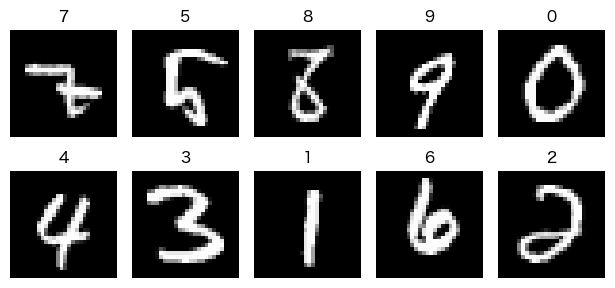

In [3]:
def show_digit_examples(dataset: Dataset, label_names: list[str], rows: int = 2, cols: int = 5) -> None:
    """MNIST の各数字を1つずつ表示する.

    Args:
        dataset: 画像とラベルを返す PyTorch dataset.
        label_names: ラベル番号に対応する表示名.
        rows: 表示する行数.
        cols: 表示する列数.
    """
    display_count = rows * cols
    display_indices: list[int] = []
    seen_labels: set[int] = set()
    for index in range(len(dataset)):
        _, label = dataset[index]
        label_id = int(label)
        if label_id in seen_labels:
            continue
        seen_labels.add(label_id)
        display_indices.append(index)
        if len(display_indices) == display_count:
            break

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.55))
    for ax, index in zip(axes.ravel(), display_indices, strict=False):
        image, label = dataset[index]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(label_names[int(label)], fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_image, sample_label = eval_dataset_raw[0]
print("image shape:", tuple(sample_image.shape))
print("label:", int(sample_label), label_names[int(sample_label)])
show_digit_examples(eval_dataset_raw, label_names)


## データ拡張で少しゆさぶる

手書き数字は，少し傾いたり，少しずれたりする。
データ拡張は，訓練中だけ画像を少し変えて，そのような違いにも強くする方法である。


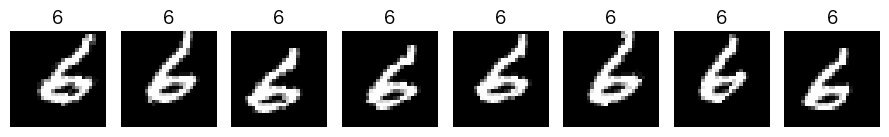

In [4]:
def show_augmentation_examples(dataset: Dataset, sample_index: int = 0, cols: int = 8) -> None:
    """同じ index の画像を何回か取り出し，データ拡張の違いを見る."""
    fig, axes = plt.subplots(1, cols, figsize=(9, 1.6))
    for ax in axes:
        image, label = dataset[sample_index]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(str(label))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_augmentation_examples(train_dataset_raw)


## `Trainer` に渡す形へそろえる

Hugging Face の `Trainer` は，入力画像を `pixel_values`，正解ラベルを `labels` という名前で受け取る。
PyTorch の dataset を，その形に合わせる。


In [5]:
class ImageDatasetForTrainer(Dataset[dict[str, torch.Tensor]]):
    """画像分類 dataset を Trainer 用の辞書形式で返す dataset."""

    def __init__(self, dataset: Dataset) -> None:
        self.dataset = dataset

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        image, label = self.dataset[index]
        return {
            "pixel_values": image,
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_dataset = ImageDatasetForTrainer(train_dataset_raw)
eval_dataset = ImageDatasetForTrainer(eval_dataset_raw)


## 小さな CNN を作る

ここでは，授業中に試しやすい小さな CNN を使う。
目的は世界最高の精度を出すことではなく，「画像を入れると，CNN が数字の手がかりを学んでいく」ことを体験することである。

ネットワーク本体は，今まで練習してきた `nn.Sequential` で1本の流れとして書く。
この節で一番見てほしいのは，`make_digit_cnn` の中にある `nn.Sequential(...)` である。
その下の `ImageClassifierForTrainer` は，`Trainer` に渡すための接続用の箱だと思えばよい。

`nn.Sequential` の中で起きることは次の通りである。

1. `Conv2d`：小さな窓で，線や角のような手がかりを探す。
2. `ReLU`：弱い反応を0にして，強く反応した場所を残す。
3. `MaxPool2d`：近い場所の反応をまとめて，画像を少し小さくする。
4. `Flatten`：画像の形を，1列の数字の並びに直す。
5. `Linear`：各数字の点数 `logits` を出す。

名前は少し難しく見えるが，ひとつひとつは部品である。
最初に触るなら，`Conv2d` の出力チャンネル数，`padding`，`Linear` の途中の数あたりから変えるとよい。
一度に全部変えると何が効いたか分からなくなるので，1か所ずつ試そう。

ここで `Conv2d(..., kernel_size=3, padding=1)` と書いている。
`kernel_size=3` は，`3 × 3` の小さな窓で画像を見るという意味である。
`padding=1` は，画像の外側に1マス分の余白を足してから畳み込むという意味である。


In [6]:
def make_digit_cnn(num_labels: int) -> nn.Sequential:
    """MNIST 用の小さな CNN を1つの Sequential として作る."""
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(32 * 7 * 7, 64),
        nn.ReLU(),
        nn.Linear(64, num_labels),
    )


class ImageClassifierForTrainer(nn.Module):
    """`Trainer` に合わせて `loss` と `logits` を返す接続用クラス."""

    def __init__(self, network: nn.Sequential) -> None:
        super().__init__()
        self.network = network
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(
        self,
        pixel_values: Float[torch.Tensor, "batch 1 28 28"],
        labels: Int64[torch.Tensor, "batch"] | None = None,
    ) -> dict[str, torch.Tensor]:
        logits = self.network(pixel_values)
        output = {"logits": logits}
        if labels is not None:
            output["loss"] = self.loss_fn(logits, labels)
        return output


network = make_digit_cnn(num_labels=len(label_names))
model = ImageClassifierForTrainer(network)
network


Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)

## padding を変えると何が起きるか

padding は，画像のまわりに足す余白のことである。
`3 × 3` の窓で `28 × 28` の画像を見るとき，padding がないと出力は `26 × 26` になる。
一方，`padding=1` にすると出力は `28 × 28` のままになる。

下のセルでは，padding の値だけを変えて，出力の形がどう変わるかを確認する。
形だけを見る実験なので，中身の重みは気にしなくてよい。


In [7]:
padding_probe = torch.zeros(1, 1, 28, 28)
for padding in [0, 1, 2]:
    conv = nn.Conv2d(1, 1, kernel_size=3, padding=padding)
    output = conv(padding_probe)
    height, width = output.shape[-2:]
    print(f"padding={padding}: 28x28 -> {height}x{width}")


padding=0: 28x28 -> 26x26
padding=1: 28x28 -> 28x28
padding=2: 28x28 -> 30x30


## 途中の形だけ見てみる

CNN の中では，画像の形が少しずつ変わる。
`Conv2d` では `padding=1` を使っているので，畳み込み直後の縦横は `28 × 28` のままである。
その後，`MaxPool2d(2)` を通るたびに，縦と横の長さが半分になる。

最初は `28 × 28` の画像だが，途中で `14 × 14`，さらに `7 × 7` と小さくなる。
これは，細かいマス目そのものより，「どこにどんな手がかりがあるか」をまとめていくためである。


In [8]:
shape_check = torch.zeros(1, 1, 28, 28)
current = shape_check
print("input:", tuple(current.shape))
for layer_index, layer in enumerate(network):
    current = layer(current)
    print(f"network[{layer_index}] {layer.__class__.__name__}:", tuple(current.shape))
print("logits:", tuple(current.shape))


input: (1, 1, 28, 28)
network[0] Conv2d: (1, 16, 28, 28)
network[1] ReLU: (1, 16, 28, 28)
network[2] MaxPool2d: (1, 16, 14, 14)
network[3] Conv2d: (1, 32, 14, 14)
network[4] ReLU: (1, 32, 14, 14)
network[5] MaxPool2d: (1, 32, 7, 7)
network[6] Flatten: (1, 1568)
network[7] Linear: (1, 64)
network[8] ReLU: (1, 64)
network[9] Linear: (1, 10)
logits: (1, 10)


## `Trainer` で訓練する

ここでは 3 epoch だけ学習する。
MNIST はかなり素直なデータなので，短い学習でも accuracy が上がりやすい。


In [9]:
def compute_accuracy(eval_pred: EvalPrediction) -> dict[str, float]:
    """Trainer の予測結果から accuracy を計算する."""
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir=tempfile.mkdtemp(prefix="mnist-cnn-"),
    num_train_epochs=3,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    learning_rate=1e-3,
    optim="adamw_torch",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    seed=SEED,
    use_cpu=DEVICE.type == "cpu",
    dataloader_pin_memory=DEVICE.type == "cuda",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_accuracy,
)

train_output = trainer.train()
eval_metrics = trainer.evaluate(eval_dataset)
eval_metrics


{'loss': '1.814', 'grad_norm': '2.003', 'learning_rate': '0.0006738', 'epoch': '1'}
{'eval_loss': '0.8112', 'eval_accuracy': '0.793', 'eval_runtime': '0.1342', 'eval_samples_per_second': '7452', 'eval_steps_per_second': '29.81', 'epoch': '1'}


{'loss': '0.9841', 'grad_norm': '1.735', 'learning_rate': '0.0003404', 'epoch': '2'}
{'eval_loss': '0.5272', 'eval_accuracy': '0.85', 'eval_runtime': '0.0373', 'eval_samples_per_second': '2.681e+04', 'eval_steps_per_second': '107.2', 'epoch': '2'}


{'loss': '0.8405', 'grad_norm': '2.301', 'learning_rate': '7.092e-06', 'epoch': '3'}
{'eval_loss': '0.4709', 'eval_accuracy': '0.866', 'eval_runtime': '0.0345', 'eval_samples_per_second': '2.897e+04', 'eval_steps_per_second': '115.9', 'epoch': '3'}
{'train_runtime': '2.565', 'train_samples_per_second': '7017', 'train_steps_per_second': '54.96', 'train_loss': '1.213', 'epoch': '3'}
{'eval_loss': '0.4709', 'eval_accuracy': '0.866', 'eval_runtime': '0.0324', 'eval_samples_per_second': '3.087e+04', 'eval_steps_per_second': '123.5', 'epoch': '3'}


{'eval_loss': 0.4708818197250366,
 'eval_accuracy': 0.866,
 'eval_runtime': 0.0324,
 'eval_samples_per_second': 30867.934,
 'eval_steps_per_second': 123.472,
 'epoch': 3.0}

## 学習の様子を見る

`loss` が下がり，`eval accuracy` が上がっていれば，モデルは数字の見分け方を少しずつ覚えている。


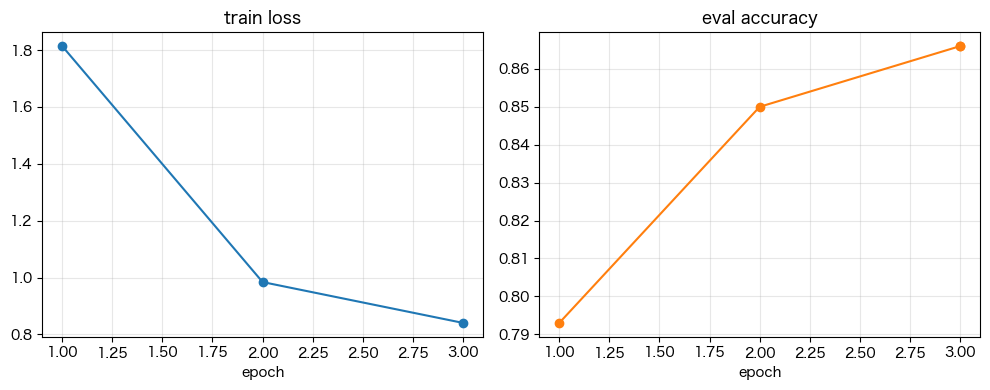

In [10]:
def plot_trainer_history(trainer: Trainer) -> None:
    """Trainer のログから loss と eval accuracy を描画する."""
    history = trainer.state.log_history
    loss_points = [(item["epoch"], item["loss"]) for item in history if "loss" in item]
    accuracy_points = [(item["epoch"], item["eval_accuracy"]) for item in history if "eval_accuracy" in item]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    if loss_points:
        epochs, losses = zip(*loss_points, strict=True)
        axes[0].plot(epochs, losses, marker="o")
    axes[0].set_title("train loss")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True, alpha=0.3)

    if accuracy_points:
        epochs, accuracies = zip(*accuracy_points, strict=True)
        axes[1].plot(epochs, accuracies, marker="o", color="tab:orange")
    axes[1].set_title("eval accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_trainer_history(trainer)


## 予測例を見る

最後に，モデルがどの数字だと思ったかを画像の上に表示する。
間違いを見つけたら，「人間でも迷う字か」「モデルだけが変な見方をしているか」を観察してみよう。


eval accuracy: 0.866 (866/1000)


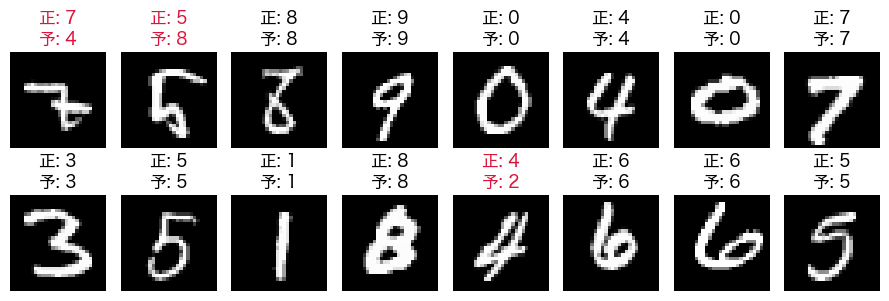

In [11]:
prediction_output = trainer.predict(eval_dataset)
y_pred = np.argmax(prediction_output.predictions, axis=1)
y_true = prediction_output.label_ids
accuracy = accuracy_score(y_true, y_pred)
print(f"eval accuracy: {accuracy:.3f} ({int((y_pred == y_true).sum())}/{len(y_true)})")

fig, axes = plt.subplots(2, 8, figsize=(9, 3.2))
for ax, index in zip(axes.ravel(), range(16), strict=False):
    image, true_label = eval_dataset_raw[index]
    predicted_label = int(y_pred[index])
    title_color = "black" if predicted_label == int(true_label) else "crimson"
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(f"正: {true_label}\n予: {predicted_label}", color=title_color)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 自作データで試す

ここまでの `eval_dataset` は，MNIST が用意しているテスト画像です。これはモデルの基本性能を見るためにそのまま使います。

次は別枠で，`data/自作手書き文字データ/` に保存した数字を「本物の未知データ」として入れてみます。黒い見出しは正解，赤い見出しは不正解です。データが増えたら，同じフォルダに追加してこのセルをもう一度実行します。


In [12]:
CUSTOM_DATASET_NAME = "自作手書き文字データ"


def normalize_path_name(name: str) -> str:
    """Unicode の濁点表現の違いをそろえて比較する."""
    return unicodedata.normalize("NFC", name)


def find_custom_handwriting_root(data_root: Path) -> Path:
    """`data` の中から自作手書き文字データのフォルダを探す."""
    target_name = normalize_path_name(CUSTOM_DATASET_NAME)
    if data_root.exists():
        for child in data_root.iterdir():
            if child.is_dir() and normalize_path_name(child.name) == target_name:
                return child
    return data_root / CUSTOM_DATASET_NAME


def path_from_metadata(root: Path, metadata: dict, key: str) -> Path | None:
    """metadata の `files` にあるファイル名を，実際の保存場所へ直す."""
    relative_name = metadata.get("files", {}).get(key)
    if not relative_name:
        return None
    candidate = root / Path(relative_name).name
    return candidate if candidate.exists() else None


def label_from_filename(path: Path) -> str | None:
    """ファイル名中の `u0030` のような Unicode 番号からラベルを読む."""
    match = re.search(r"_u([0-9A-Fa-f]{4,6})_", path.name)
    if match is None:
        return None
    return chr(int(match.group(1), 16))


def foreground_image(image: Image.Image) -> Image.Image:
    """背景が0，文字が明るい値になる1チャンネル画像へそろえる."""
    rgba = image.convert("RGBA")
    background = Image.new("RGBA", rgba.size, (0, 0, 0, 255))
    gray = Image.alpha_composite(background, rgba).convert("L")
    array = np.asarray(gray, dtype=np.uint8)
    border = np.concatenate([
        array[0, :],
        array[-1, :],
        array[:, 0],
        array[:, -1],
    ])
    if np.median(border) > 127:
        array = 255 - array
    return Image.fromarray(array, mode="L")


def custom_digit_transform(image: Image.Image) -> Float[torch.Tensor, "1 28 28"]:
    """自作数字画像を MNIST に近い 28x28 Tensor へ変換する."""
    image = foreground_image(image)
    array = np.asarray(image, dtype=np.uint8)
    mask = array > 16
    bbox = Image.fromarray((mask.astype(np.uint8) * 255), mode="L").getbbox()
    if bbox is not None:
        image = image.crop(bbox)

    image.thumbnail((20, 20), Image.Resampling.LANCZOS)
    canvas = Image.new("L", (28, 28), 0)
    left = (28 - image.width) // 2
    top = (28 - image.height) // 2
    canvas.paste(image, (left, top))
    return transforms.ToTensor()(canvas)


class CustomHandwritingDataset(Dataset[tuple[Float[torch.Tensor, "1 28 28"], int]]):
    """`data/自作手書き文字データ` から指定した種類の画像を読む dataset."""

    def __init__(self, root: Path, collection: str, label_names: list[str]) -> None:
        self.samples: list[tuple[Path, int]] = []
        self.skipped: list[Path] = []
        self.root = root
        class_to_idx = {label: index for index, label in enumerate(label_names)}

        if not root.exists():
            return

        used_image_names: set[str] = set()
        for metadata_path in sorted(root.glob(f"{collection}_*_metadata.json")):
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
            if metadata.get("collection") != collection:
                continue
            label = str(metadata.get("label", ""))
            image_path = path_from_metadata(root, metadata, "etl8g_png") or path_from_metadata(root, metadata, "raw_png")
            if image_path is None or label not in class_to_idx:
                self.skipped.append(metadata_path)
                continue
            self.samples.append((image_path, class_to_idx[label]))
            used_image_names.add(image_path.name)

        for image_path in sorted(root.glob(f"{collection}_*.png")):
            if image_path.name in used_image_names or "_128x127" not in image_path.stem:
                continue
            label = label_from_filename(image_path)
            if label is None or label not in class_to_idx:
                self.skipped.append(image_path)
                continue
            self.samples.append((image_path, class_to_idx[label]))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> tuple[Float[torch.Tensor, "1 28 28"], int]:
        image_path, label = self.samples[index]
        with Image.open(image_path) as image:
            return custom_digit_transform(image), label


def select_prediction_grid_indices(
    predicted_labels: np.ndarray,
    true_labels: np.ndarray,
    max_images: int,
) -> list[int]:
    """表示枚数が多すぎるとき，正解例と不正解例が混ざるように選ぶ."""
    all_indices = list(range(len(true_labels)))
    if len(all_indices) <= max_images:
        return all_indices

    correct_indices = [
        index
        for index, (predicted, true) in enumerate(zip(predicted_labels, true_labels, strict=True))
        if int(predicted) == int(true)
    ]
    correct_index_set = set(correct_indices)
    wrong_indices = [index for index in all_indices if index not in correct_index_set]
    if not correct_indices or not wrong_indices:
        return all_indices[:max_images]

    correct_count = min(len(correct_indices), max_images // 2)
    wrong_count = max_images - correct_count
    selected = wrong_indices[:wrong_count] + correct_indices[:correct_count]
    return selected[:max_images]


def show_prediction_grid(
    dataset: Dataset[tuple[Float[torch.Tensor, "1 28 28"], int]],
    predicted_labels: np.ndarray,
    true_labels: np.ndarray,
    label_names: list[str],
    max_images: int = 16,
    cols: int = 8,
) -> None:
    """正解と予測を，正解なら黒，不正解なら赤で表示する."""
    selected_indices = select_prediction_grid_indices(predicted_labels, true_labels, max_images)
    display_count = len(selected_indices)
    if display_count == 0:
        print("表示できる自作データがありません。")
        return

    rows = (display_count + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.85))
    axes_array = np.atleast_1d(axes).ravel()
    for ax in axes_array:
        ax.axis("off")

    for ax, index in zip(axes_array, selected_indices, strict=False):
        image, true_label = dataset[index]
        predicted_label = int(predicted_labels[index])
        true_label = int(true_labels[index])
        title_color = "black" if predicted_label == true_label else "crimson"
        ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
        ax.set_title(
            f"正: {label_names[true_label]}\n予: {label_names[predicted_label]}",
            color=title_color,
            fontsize=10,
            fontweight="bold",
        )
    plt.tight_layout()
    plt.show()


custom_handwriting_root = find_custom_handwriting_root(DATA_ROOT)
custom_digit_dataset_raw = CustomHandwritingDataset(
    root=custom_handwriting_root,
    collection="digits",
    label_names=label_names,
)
custom_digit_dataset = ImageDatasetForTrainer(custom_digit_dataset_raw)

print("custom data directory:", custom_handwriting_root)
print("custom digit samples:", len(custom_digit_dataset_raw))
print("skipped files:", len(custom_digit_dataset_raw.skipped))


custom data directory: ../data/自作手書き文字データ
custom digit samples: 13
skipped files: 0


custom digit accuracy: 0.615 (8/13)


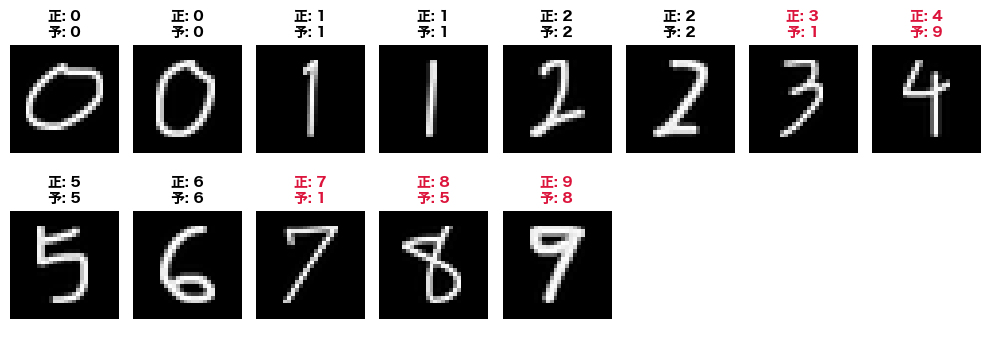

In [13]:
if len(custom_digit_dataset_raw) == 0:
    print("自作数字データがまだありません。追加したら，このセルをもう一度実行してください。")
else:
    custom_prediction_output = trainer.predict(custom_digit_dataset)
    custom_y_pred = np.argmax(custom_prediction_output.predictions, axis=1)
    custom_y_true = custom_prediction_output.label_ids
    custom_accuracy = accuracy_score(custom_y_true, custom_y_pred)
    correct_count = int((custom_y_pred == custom_y_true).sum())
    print(
        f"custom digit accuracy: {custom_accuracy:.3f} "
        f"({correct_count}/{len(custom_y_true)})"
    )
    show_prediction_grid(
        custom_digit_dataset_raw,
        custom_y_pred,
        custom_y_true,
        label_names,
        max_images=16,
        cols=8,
    )


## まとめ

この notebook では，MNIST Digits を使って CNN の基本の流れを試した。

- CNN は，小さな範囲を見ながら画像の手がかりを探す。
- `padding` は，画像の端も見やすくし，形を調整するために使う。
- `pooling` は，近くの情報をまとめて，少しの位置ずれに強くする。
- データ拡張は，訓練画像を少し変えて，いろいろな書き方を練習させる。
- `Trainer` を使うと，自分で作った `nn.Sequential` の CNN でも短いコードで学習できる。

次は，もっと難しいひらがなや犬猫写真に進む。
